In [12]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import glob
import seaborn as sns
import matplotlib.pyplot as plt
from NanoparticlesSAM.particle_stats import *
from NanoparticlesSAM.particle_seg import *

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [74]:
foldername = 'results/20250324-sam2/'
pickels = glob.glob(f'{foldername}/*pkl')

df_list = []
for file in pickels:
    df_list.append(pd.read_pickle(file))

df = pd.concat(df_list)
#df['nm_per_pixel']  = df['nm_estimated_radius'] / df['estimated_radius']

In [75]:
print(df.shape)
df.head()

(995, 21)


,segmentation,area,bbox,predicted_iou,point_coords,stability_score,crop_box,smooth_mask,perimeter,smooth_area,...,estimated_radius,point_coords_tuple,feret_diameter,min_feret_diameter,nm_feret_radius,nm_estimated_radius,nm_min_feret_diameter,img_name,experiment,nm_per_pixel
0,"[[False, False, False, False, False, False, Fa...",27416,"[245.0, 315.0, 186.0, 186.0]",0.992188,"[[300.0, 345.0]]",0.989878,"[0.0, 0.0, 1280.0, 960.0]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",749,27416.0,...,93.417257,"(300.0, 345.0)",189.842040,183.989182,118.651275,116.771571,229.986477,A2-01,A2-1h (1),1.25
1,"[[False, False, False, False, False, False, Fa...",27407,"[245.0, 315.0, 357.0, 186.0]",0.992188,"[[260.0, 375.0]]",0.989798,"[0.0, 0.0, 1280.0, 960.0]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",749,27404.0,...,93.401922,"(260.0, 375.0)",189.612763,184.118912,118.507977,116.752403,230.148640,A2-01,A2-1h (1),1.25
2,"[[False, False, False, False, False, False, Fa...",28094,"[659.0, 304.0, 190.0, 189.0]",0.988281,"[[740.0, 315.0]]",0.990155,"[0.0, 0.0, 1280.0, 960.0]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",763,28094.0,...,94.565310,"(740.0, 315.0)",193.209731,187.528549,120.756082,118.206638,234.410686,A2-01,A2-1h (1),1.25
3,"[[False, False, False, False, False, False, Fa...",27833,"[547.0, 444.0, 184.0, 192.0]",0.988281,"[[620.0, 465.0]]",0.984989,"[0.0, 0.0, 1280.0, 960.0]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",755,27832.0,...,94.125018,"(620.0, 465.0)",198.736006,185.113266,124.210004,117.656273,231.391582,A2-01,A2-1h (1),1.25
4,"[[False, False, False, False, False, False, Fa...",28092,"[356.0, 465.0, 189.0, 189.0]",0.988281,"[[420.0, 495.0]]",0.988317,"[0.0, 0.0, 1280.0, 960.0]","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",761,28092.0,...,94.561944,"(420.0, 495.0)",194.257561,183.337051,121.410976,118.202430,229.171314,A2-01,A2-1h (1),1.25


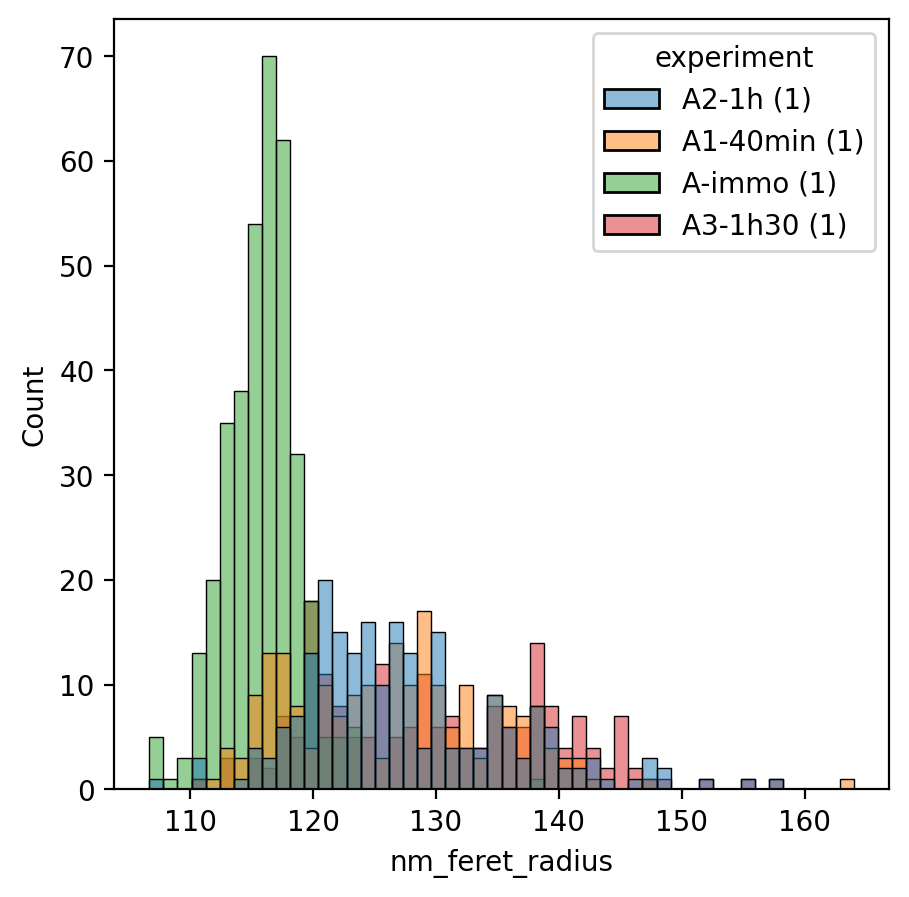

In [76]:
plt.figure(figsize=(5,5), dpi=200)
sns.histplot(data=df, x='nm_feret_radius', hue='experiment', bins=50)
plt.savefig(f'{foldername}/unfiltered_measurements')

In [77]:
#exclusion_list = ['A1-01', 'A1-04', 'A1-02', 'B3-01','B2-05','B2-04','B2-03','B2-02'] #20250224
#exclusion_list = [ 'A1-04', 'A1-12', 'A1-17','A1-18','A1-19', 'A2-08', 'A3-15', 'A3-16', 'A3-17', 'A3-20'] #20250324
exclusion_list = [] #20250324-2

In [78]:
df_filtered = df[~df['img_name'].isin(exclusion_list)]
df_filtered.shape

(995, 21)

In [79]:
df_filtered = df_filtered.query("circularity > 0.65")
df_filtered.shape

(995, 21)

In [81]:
df_filtered['hough_radius'] = df_filtered.apply(lambda x: get_hough_radius(x['smooth_mask'], 
                                                                           dp=2, 
                                                                           nm_min_radius=70, 
                                                                           nm_max_radius=150, 
                                                                           nm_per_pixel=x['nm_per_pixel'], 
                                                                           convert_to_nm=True), axis=1)

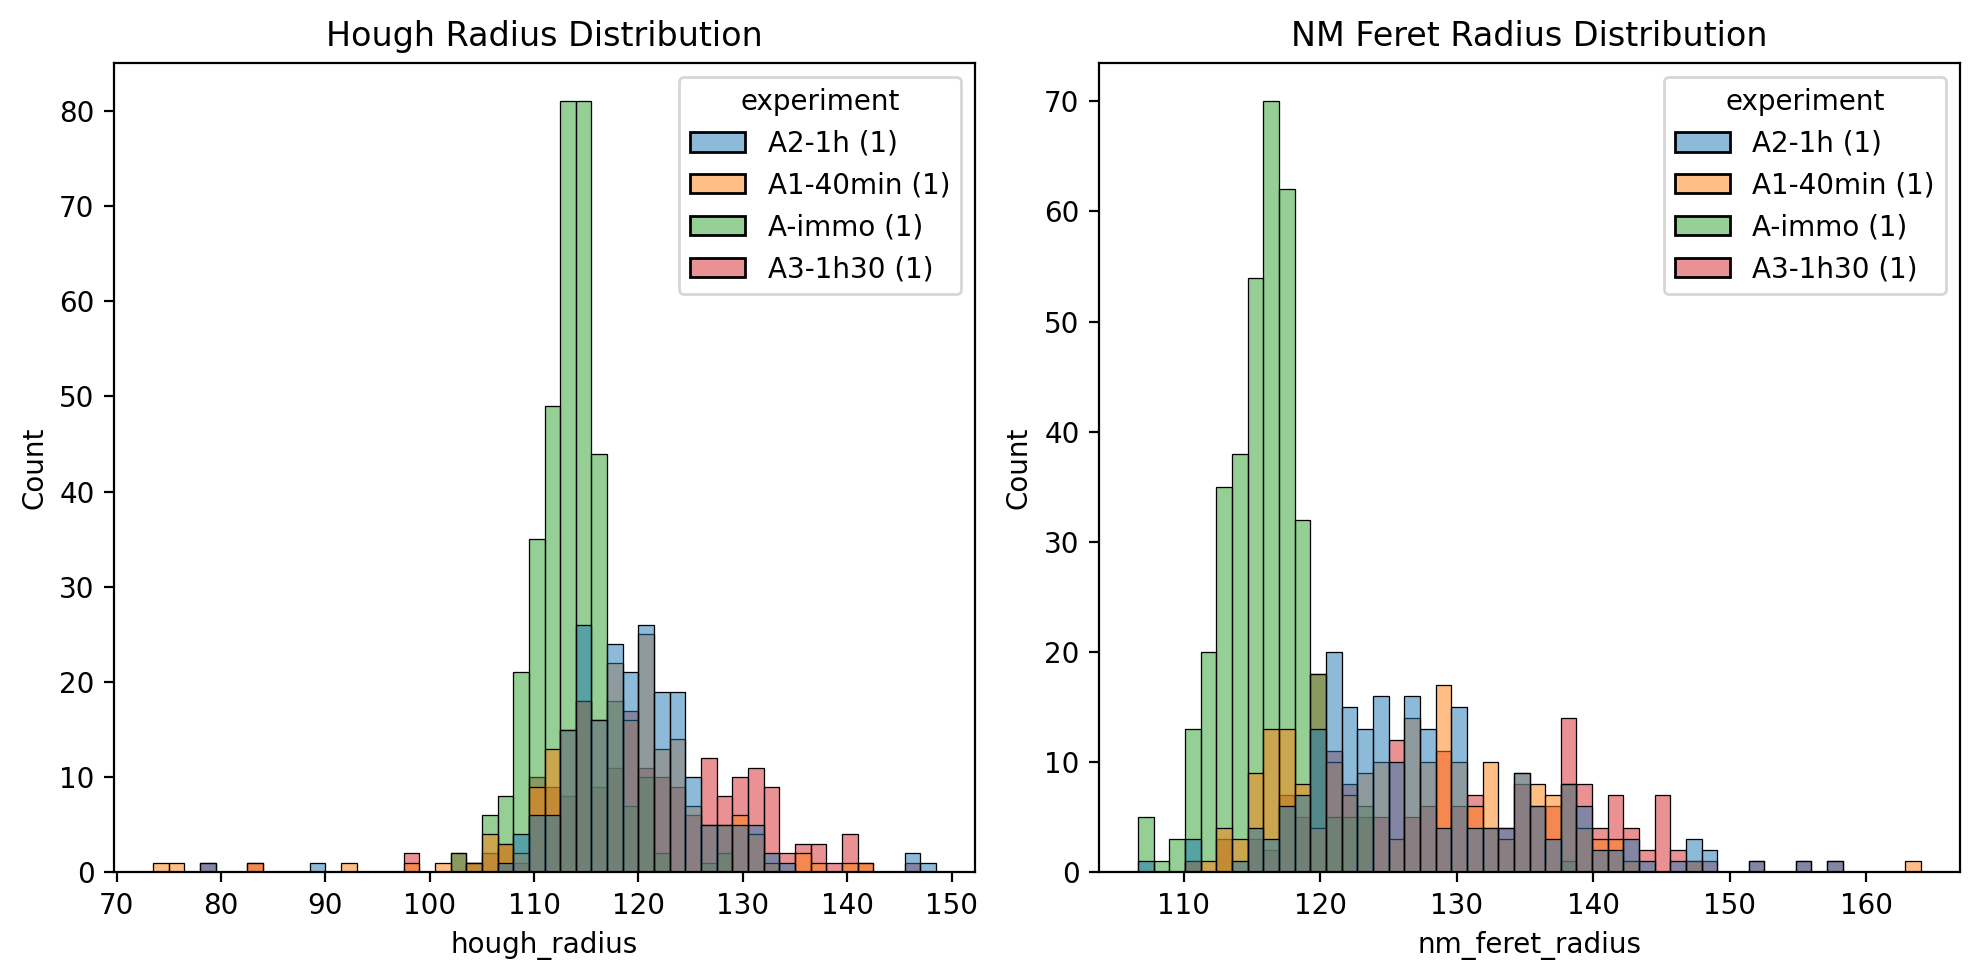

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=200)

sns.histplot(data=df_filtered.dropna(), x='hough_radius', hue='experiment', bins=50, ax=axes[0])
axes[0].set_title("Hough Radius Distribution")

sns.histplot(data=df_filtered.dropna(), x='nm_feret_radius', hue='experiment', bins=50, ax=axes[1])
axes[1].set_title("NM Feret Radius Distribution")
plt.tight_layout()

# Save the figure
plt.savefig(f'{foldername}/unfiltered_measurements')
plt.show()

In [96]:
filter_quantity =  'hough_radius' 
#filter_quantity = 'nm_feret_radius' 
q5, q95 = df_filtered[filter_quantity].quantile([0.05, 0.95])
df_filtered = df_filtered[(df_filtered[filter_quantity] < q95) & (df_filtered[filter_quantity] > q5)]

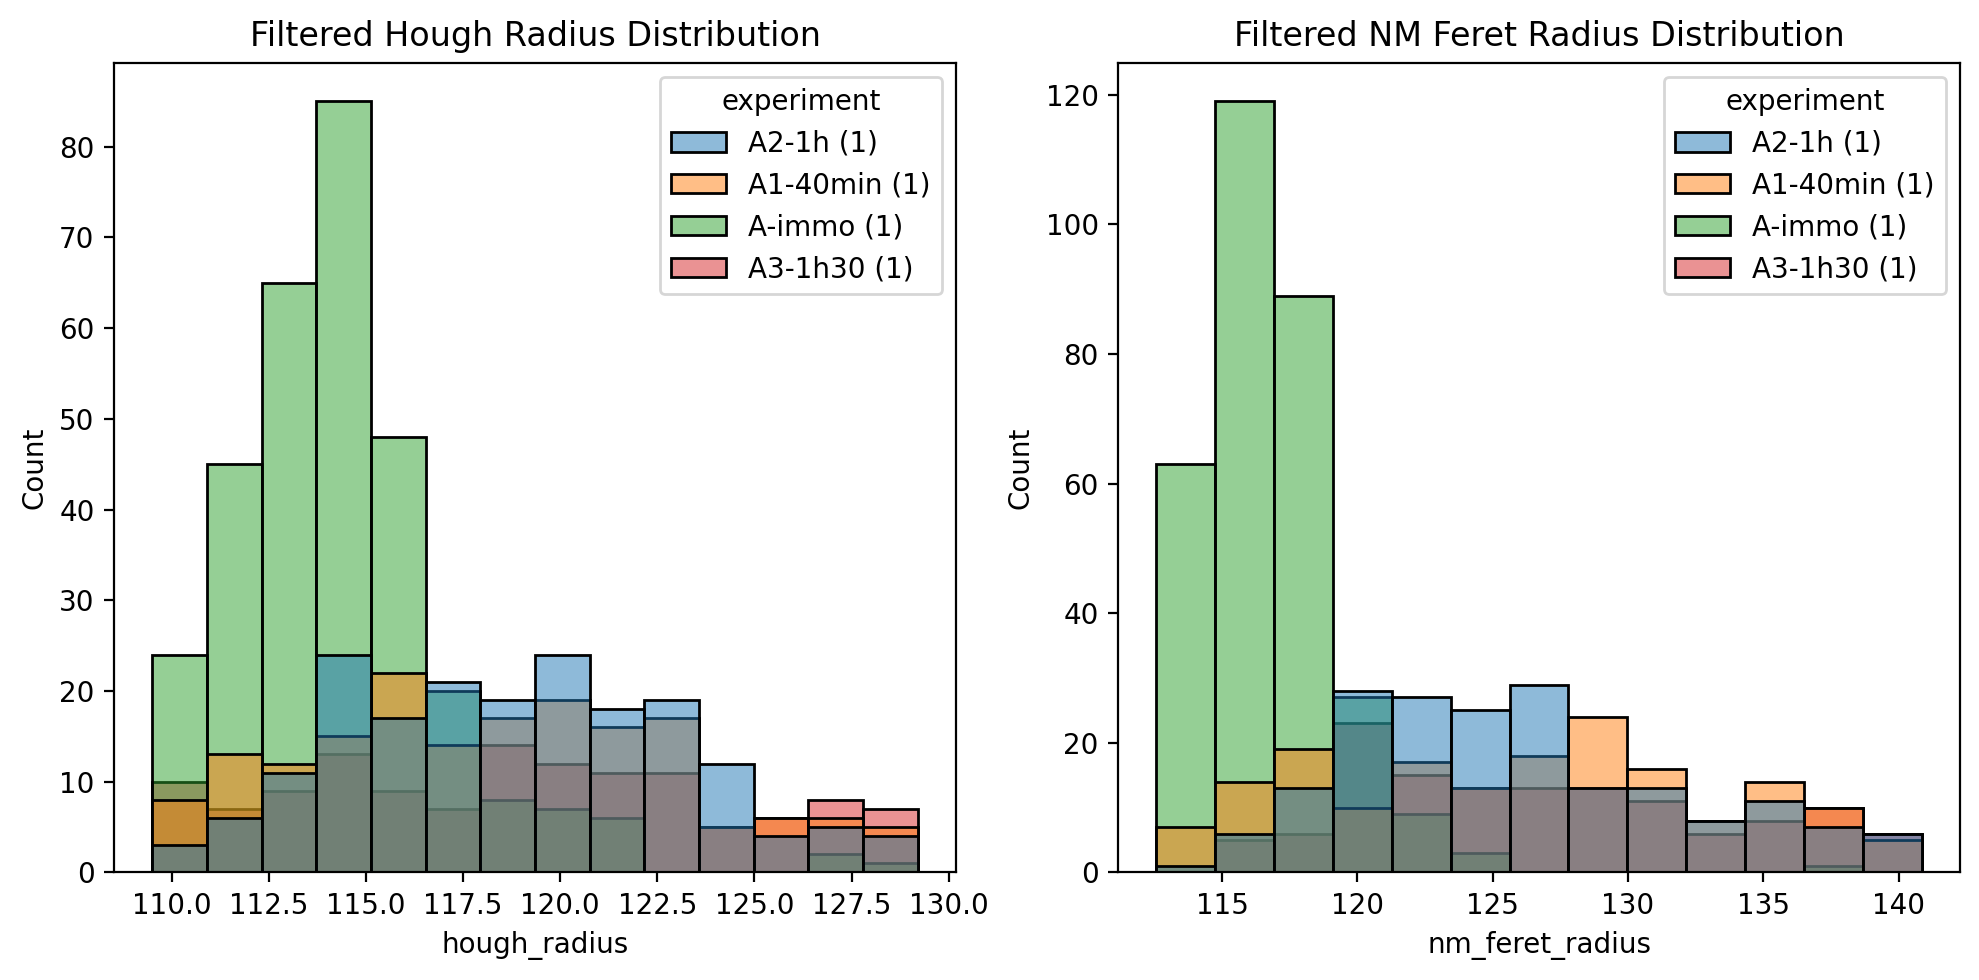

In [97]:
plot_df = df_filtered.dropna()

fig, axes = plt.subplots(1, 2, figsize=(10, 5), dpi=200)

sns.histplot(data=plot_df, x='hough_radius', hue='experiment', ax=axes[0])
axes[0].set_title("Filtered Hough Radius Distribution")

sns.histplot(data=plot_df, x='nm_feret_radius', hue='experiment', ax=axes[1])
axes[1].set_title("Filtered NM Feret Radius Distribution")

plt.tight_layout()

plt.savefig(f'{foldername}/filtered_particle_measurements')
plt.show()


<Figure size 1000x1000 with 0 Axes>

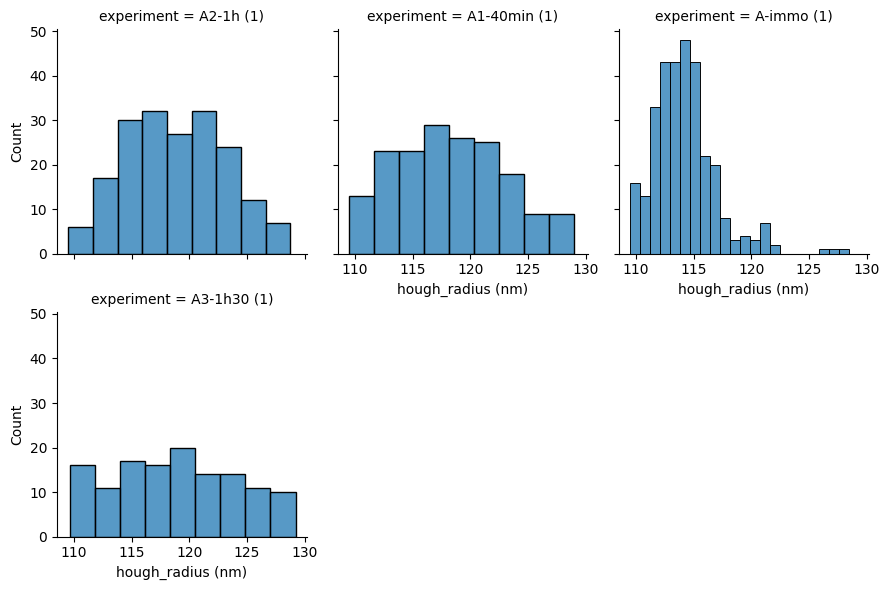

In [98]:
plt.figure(figsize=(5,5), dpi=200)
g = sns.FacetGrid(plot_df, col='experiment', col_wrap=3)
g.map(sns.histplot, filter_quantity)
g.set_axis_labels(f"{filter_quantity} (nm)", "Count")
plt.savefig(f'{foldername}/histogram-grid')

In [105]:
filter_quantity =  'hough_radius' 
filter_quantity = 'nm_feret_radius' 

experiment_df = df_filtered.reset_index().pivot(columns='experiment', values=filter_quantity)
experiment_df = experiment_df.apply(lambda x: pd.Series(x.dropna().values))
#experiment_df = remove_outliers_df(experiment_df)
experiment_df.head()

experiment,A-immo (1),A1-40min (1),A2-1h (1),A3-1h30 (1)
0,116.256720,117.924764,118.651275,138.103788
1,115.888214,118.389255,118.507977,137.820649
2,116.520183,122.907486,120.756082,137.683117
3,117.197083,122.719828,124.210004,128.617954
4,113.636619,121.476914,121.410976,128.239278


In [106]:
experiment_df.describe().to_excel(f'{foldername}/individual-particle-analysis.xlsx')
experiment_df.describe()

experiment,A-immo (1),A1-40min (1),A2-1h (1),A3-1h30 (1)
count,311.000000,175.000000,187.000000,129.000000
mean,116.720620,126.102715,125.898314,126.850723
std,2.532926,7.159751,6.011653,6.644588
min,112.571158,112.960862,114.690480,115.637283
25%,115.282432,120.384295,121.203275,121.173164
50%,116.640808,126.503458,124.607195,125.670433
75%,117.916483,131.275291,129.733799,131.625950
max,138.430093,140.852594,140.184031,140.549846


In [107]:
analysis_df = analyze_samples(experiment_df, 'A-immo (1)', alpha=0.01)
analysis_df.to_csv(f'{foldername}/shield-analysis.csv')
analysis_df.to_excel(f'{foldername}/shield-analysis.xlsx')
analysis_df

,A1-40min (1),A2-1h (1),A3-1h30 (1)
thickness,9.382095,9.177694,10.130103
CI_lower,7.92576,7.976286,8.557559
CI_upper,10.83843,10.379103,11.702647
p_value,0.0,0.0,0.0
significance,Significant,Significant,Significant
significance_level,99.5,99.5,99.5
SEM,0.55996,0.462484,0.602397
DOF,198.817404,226.280634,143.679932
N_sample,175,187,129
N_ref,311,311,311


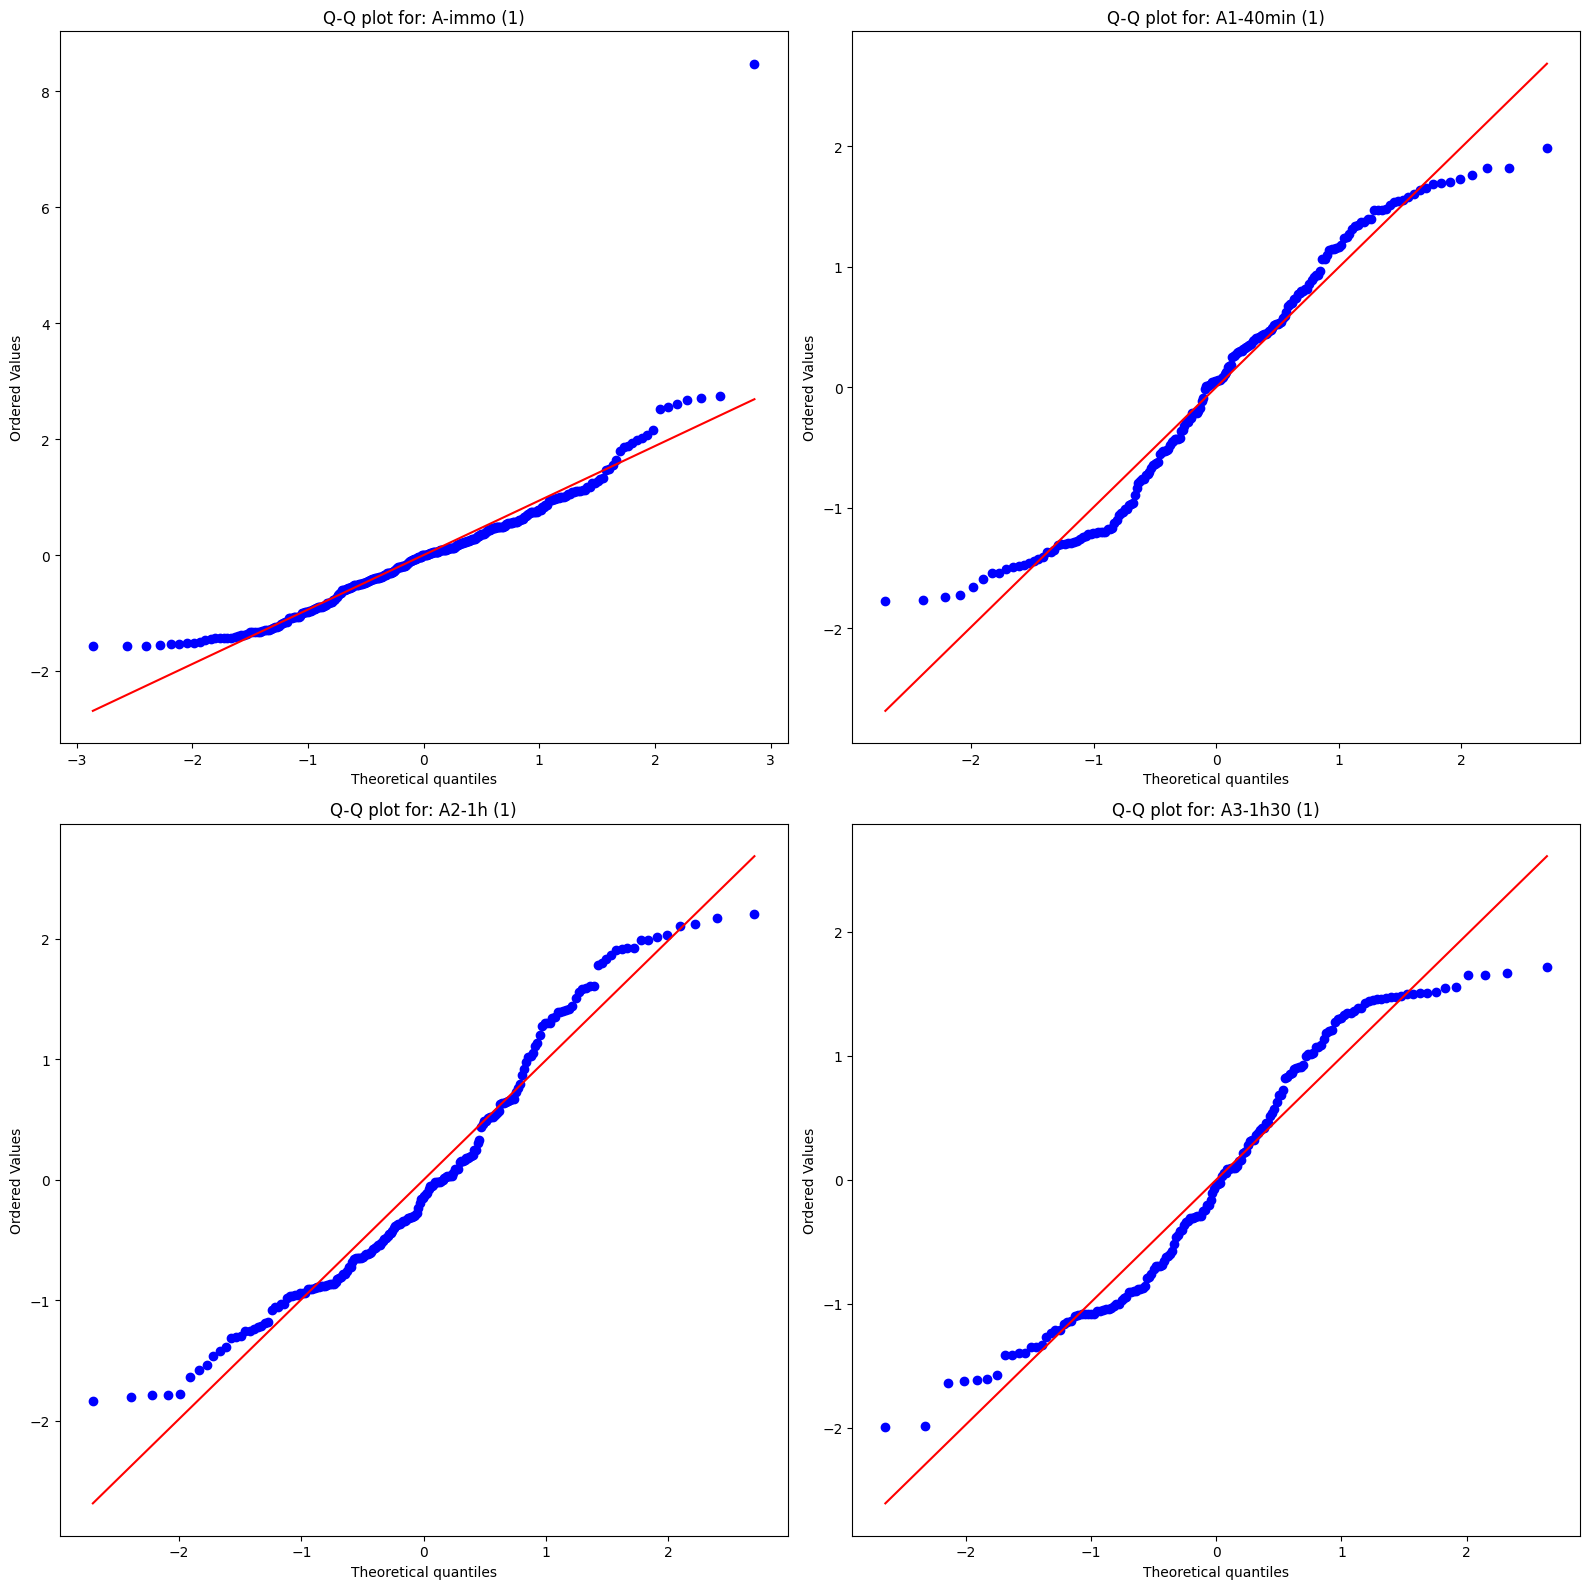

<Figure size 640x480 with 0 Axes>

In [95]:
plot_quantiles(experiment_df, foldername)